In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_deriv(a):
    return a * (1 - a)


def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

In [3]:
class NeuralNetwork:
    def __init__(self, layer_sizes, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.lr = lr
        self.weights, self.biases = [], []
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            w = rng.randn(fan_in, layer_sizes[i + 1]) * np.sqrt(1 / fan_in)
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        activations = [X]
        a = X
        for w, b in zip(self.weights, self.biases):
            a = sigmoid(a @ w + b)
            activations.append(a)
        return activations

    def backward(self, activations, y):
        m = y.shape[0]
        output = activations[-1]
        delta = (output - y) * sigmoid_deriv(output)

        grads_w, grads_b = [None] * len(self.weights), [None] * len(self.weights)
        for i in reversed(range(len(self.weights))):
            grads_w[i] = activations[i].T @ delta / m
            grads_b[i] = np.mean(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * sigmoid_deriv(activations[i])

        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_w[i]
            self.biases[i] -= self.lr * grads_b[i]

    def train_epoch(self, X, y, batch_size):
        n = X.shape[0]
        idx = np.random.permutation(n)
        Xs, ys = X[idx], y[idx]
        total_loss = 0.0
        for start in range(0, n, batch_size):
            end = start + batch_size
            xb, yb = Xs[start:end], ys[start:end]
            acts = self.forward(xb)
            total_loss += np.mean((acts[-1] - yb) ** 2) * len(xb)
            self.backward(acts, yb)
        return total_loss / n

    def fit(self, X, y, epochs, batch_size, verbose_every=None):
        history = []
        for epoch in range(epochs):
            loss = self.train_epoch(X, y, batch_size)
            history.append(loss)
            if verbose_every and (epoch + 1) % verbose_every == 0:
                print(f"epoch {epoch + 1:>4}/{epochs}  loss={loss:.5f}")
        return history

    def predict(self, X):
        return self.forward(X)[-1]

### 1. Binary classification — Iris, versicolor vs. virginica

In [4]:
iris = load_iris()
X_all, y_all = iris.data, iris.target

mask = y_all != 0
Xb, yb = X_all[mask], y_all[mask]
yb = (yb == 2).astype(int)  # 0 = versicolor, 1 = virginica

Xb = StandardScaler().fit_transform(Xb)
Yb = yb.reshape(-1, 1)

Xb_train, Xb_test, Yb_train, Yb_test, yb_train, yb_test = train_test_split(
    Xb, Yb, yb, test_size=0.2, random_state=42, stratify=yb
)

nn_binary = NeuralNetwork(layer_sizes=[4, 6, 1], lr=0.3, seed=42)
nn_binary.fit(Xb_train, Yb_train, epochs=300, batch_size=8)

pred_binary = (nn_binary.predict(Xb_test) >= 0.5).astype(int).ravel()
print(f"Binary (versicolor vs virginica) test accuracy: {accuracy_score(yb_test, pred_binary) * 100:.2f}%")
print(classification_report(yb_test, pred_binary, target_names=["versicolor", "virginica"]))

Binary (versicolor vs virginica) test accuracy: 95.00%
              precision    recall  f1-score   support

  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



### 2. Multi-class — full Iris (3 classes)



In [5]:
y_iris_onehot = one_hot(y_all, 3)
X_iris = StandardScaler().fit_transform(X_all)

Xi_train, Xi_test, Yi_train, Yi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris_onehot, y_all, test_size=0.2, random_state=42, stratify=y_all
)

nn_iris = NeuralNetwork(layer_sizes=[4, 8, 3], lr=0.3, seed=42)
loss_iris = nn_iris.fit(Xi_train, Yi_train, epochs=300, batch_size=8, verbose_every=50)

epoch   50/300  loss=0.07336
epoch  100/300  loss=0.03760
epoch  150/300  loss=0.02237
epoch  200/300  loss=0.01694
epoch  250/300  loss=0.01447
epoch  300/300  loss=0.01321


IRIS (from scratch) test accuracy: 96.67%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



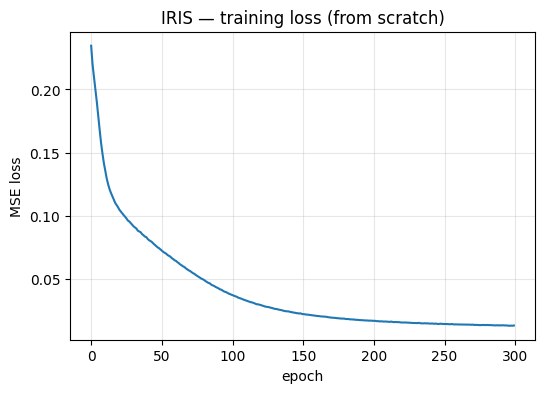

In [6]:
pred_iris = np.argmax(nn_iris.predict(Xi_test), axis=1)
acc_iris_scratch = accuracy_score(yi_test, pred_iris)

print(f"IRIS (from scratch) test accuracy: {acc_iris_scratch * 100:.2f}%")
print(classification_report(yi_test, pred_iris, target_names=iris.target_names))

plt.figure(figsize=(6, 4))
plt.plot(loss_iris)
plt.title("IRIS — training loss (from scratch)")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.grid(alpha=0.3)
plt.show()

### 3. Multi-class — MNIST


In [8]:
from tensorflow.keras.datasets import mnist

In [9]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full.reshape(-1, 784).astype(np.float32) / 255.0
X_test_full = X_test_full.reshape(-1, 784).astype(np.float32) / 255.0

X_train_m, y_train_m = X_train_full[:10000], y_train_full[:10000]
X_test_m, y_test_m = X_test_full[:2000], y_test_full[:2000]

Y_train_m = one_hot(y_train_m, 10)

In [10]:
nn_mnist = NeuralNetwork(layer_sizes=[784, 128, 64, 10], lr=0.3, seed=42)

start = time.time()
loss_mnist = nn_mnist.fit(X_train_m, Y_train_m, epochs=40, batch_size=64, verbose_every=5)
train_time_scratch_mnist = time.time() - start

print(f"\ntraining took {train_time_scratch_mnist:.1f} seconds")

epoch    5/40  loss=0.08693
epoch   10/40  loss=0.05613
epoch   15/40  loss=0.03775
epoch   20/40  loss=0.02779
epoch   25/40  loss=0.02185
epoch   30/40  loss=0.01855
epoch   35/40  loss=0.01659
epoch   40/40  loss=0.01520

training took 21.8 seconds


MNIST (from scratch) test accuracy: 87.35%
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       175
           1       0.94      0.97      0.96       234
           2       0.88      0.85      0.87       219
           3       0.89      0.83      0.85       207
           4       0.89      0.89      0.89       217
           5       0.81      0.84      0.82       179
           6       0.85      0.90      0.87       178
           7       0.89      0.83      0.86       205
           8       0.86      0.78      0.82       192
           9       0.83      0.86      0.85       194

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



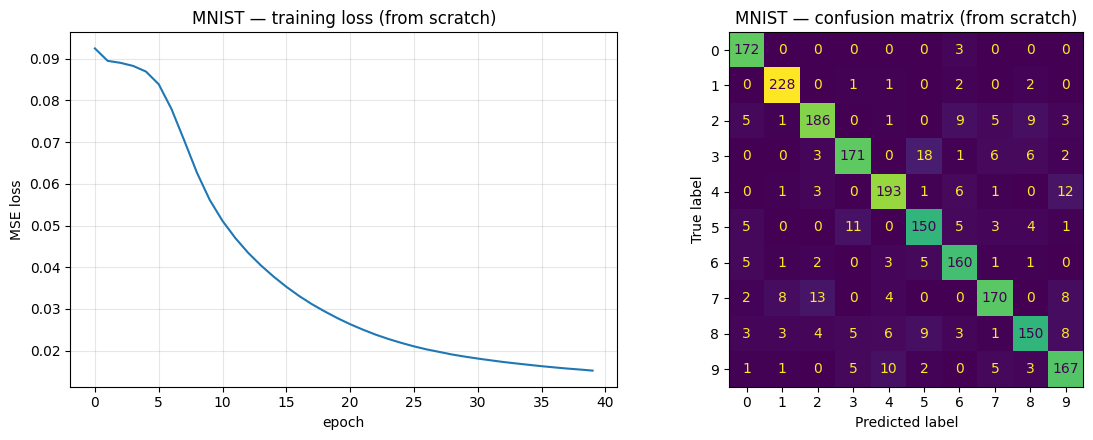

In [11]:
pred_mnist = np.argmax(nn_mnist.predict(X_test_m), axis=1)
acc_mnist_scratch = accuracy_score(y_test_m, pred_mnist)

print(f"MNIST (from scratch) test accuracy: {acc_mnist_scratch * 100:.2f}%")
print(classification_report(y_test_m, pred_mnist))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(loss_mnist)
axes[0].set_title("MNIST — training loss (from scratch)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay.from_predictions(y_test_m, pred_mnist, ax=axes[1], colorbar=False)
axes[1].set_title("MNIST — confusion matrix (from scratch)")
plt.tight_layout()
plt.show()

## Part 2 — The same models in Keras


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

In [13]:
# binary — versicolor vs virginica
model_binary = keras.Sequential([
    layers.Dense(6, activation="sigmoid", input_shape=(4,)),
    layers.Dense(1, activation="sigmoid"),
])
model_binary.compile(optimizer="adam", loss="mse", metrics=["accuracy"])

model_binary.fit(Xb_train, Yb_train, epochs=100, batch_size=8, verbose=0)

pred_binary_keras = (model_binary.predict(Xb_test, verbose=0) >= 0.5).astype(int).ravel()
acc_binary_keras = accuracy_score(yb_test, pred_binary_keras)
print(f"Keras binary (versicolor vs virginica) accuracy: {acc_binary_keras * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras binary (versicolor vs virginica) accuracy: 85.00%


In [14]:
# multi-class — full IRIS
model_iris = keras.Sequential([
    layers.Dense(8, activation="sigmoid", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid"),
])
model_iris.compile(optimizer="adam", loss="mse", metrics=["accuracy"])

history_iris = model_iris.fit(
    Xi_train, Yi_train, epochs=100, batch_size=8, verbose=0, validation_split=0.1
)

pred_iris_keras = np.argmax(model_iris.predict(Xi_test, verbose=0), axis=1)
acc_iris_keras = accuracy_score(yi_test, pred_iris_keras)
print(f"Keras IRIS accuracy: {acc_iris_keras * 100:.2f}%")
print(classification_report(yi_test, pred_iris_keras, target_names=iris.target_names))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras IRIS accuracy: 76.67%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.30      0.46        10
   virginica       0.59      1.00      0.74        10

    accuracy                           0.77        30
   macro avg       0.86      0.77      0.73        30
weighted avg       0.86      0.77      0.73        30



In [15]:
# multi-class — MNIST
Y_train_full = one_hot(y_train_full, 10)

model_mnist = keras.Sequential([
    layers.Dense(128, activation="sigmoid", input_shape=(784,)),
    layers.Dense(64, activation="sigmoid"),
    layers.Dense(10, activation="sigmoid"),
])
model_mnist.compile(optimizer="adam", loss="mse", metrics=["accuracy"])

start = time.time()
history_mnist = model_mnist.fit(
    X_train_full, Y_train_full, epochs=15, batch_size=128, verbose=1, validation_split=0.1
)
train_time_keras_mnist = time.time() - start

pred_mnist_keras = np.argmax(model_mnist.predict(X_test_full, verbose=0), axis=1)
acc_mnist_keras = accuracy_score(y_test_full, pred_mnist_keras)
print(f"\nKeras MNIST accuracy: {acc_mnist_keras * 100:.2f}%  (trained in {train_time_keras_mnist:.1f}s on the full 60k set)")
print(classification_report(y_test_full, pred_mnist_keras))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6005 - loss: 0.0666 - val_accuracy: 0.9045 - val_loss: 0.0293
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9019 - loss: 0.0217 - val_accuracy: 0.9355 - val_loss: 0.0135
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9241 - loss: 0.0138 - val_accuracy: 0.9460 - val_loss: 0.0099
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9378 - loss: 0.0109 - val_accuracy: 0.9555 - val_loss: 0.0081
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9473 - loss: 0.0091 - val_accuracy: 0.9620 - val_loss: 0.0070
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9546 - loss: 0.0078 - val_accuracy: 0.9647 - val_loss: 0.0062
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9609 - loss: 0.0068 - val_accuracy: 0.9685 - val_loss: 0.0056
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9660 - loss: 0.0060 - val_accuracy: 0.

## Part 3 — Comparison

In [16]:
import pandas as pd

comparison = pd.DataFrame({
    "Dataset": ["Iris (binary)", "Iris (3-class)", "MNIST"],
    "From scratch": [f"{accuracy_score(yb_test, pred_binary)*100:.2f}%",
                      f"{acc_iris_scratch*100:.2f}%",
                      f"{acc_mnist_scratch*100:.2f}%"],
    "Keras":        [f"{acc_binary_keras*100:.2f}%",
                      f"{acc_iris_keras*100:.2f}%",
                      f"{acc_mnist_keras*100:.2f}%"],
    "Scratch training data": ["120 rows", "120 rows", "10,000 / 60,000 images"],
    "Scratch train time": ["<1s", "<1s", f"{train_time_scratch_mnist:.1f}s"],
    "Keras train time": ["~2s", "~2s", f"{train_time_keras_mnist:.1f}s"],
})
comparison

,Dataset,From scratch,Keras,Scratch training data,Scratch train time,Keras train time
0,Iris (binary),95.00%,85.00%,120 rows,<1s,~2s
1,Iris (3-class),96.67%,76.67%,120 rows,<1s,~2s
2,MNIST,87.35%,97.31%,"10,000 / 60,000 images",21.8s,43.3s


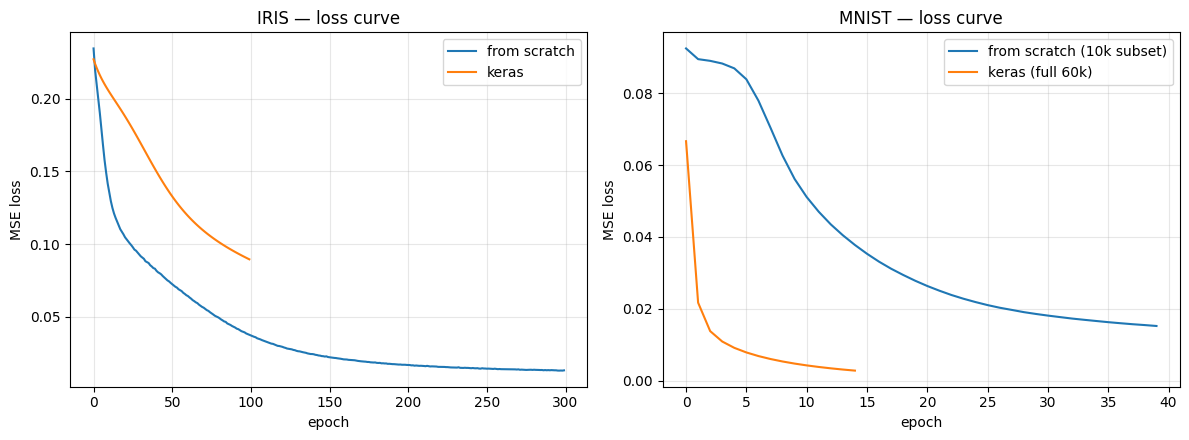

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(loss_iris, label="from scratch")
axes[0].plot(history_iris.history["loss"], label="keras")
axes[0].set_title("IRIS — loss curve")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss_mnist, label="from scratch (10k subset)")
axes[1].plot(history_mnist.history["loss"], label="keras (full 60k)")
axes[1].set_title("MNIST — loss curve")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()